In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid", rc={"figure.figsize": (10, 6)})

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbor': KNeighborsClassifier(),
    'Support Vector Machine': SVC(random_state=42)
}

In [2]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, sep=';')

df.drop('id', axis=1, inplace=True)
df.drop(df.tail(1).index, inplace=True)

print("Shape:", df.shape)
df.head()


Saving cardio_train.csv to cardio_train (1).csv
Shape: (69999, 12)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df['age'] = (df['age'] / 365).round().astype(int)

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

df = df[(df['ap_hi'] > 0) & (df['ap_lo'] > 0) & (df['ap_hi'] < 300) & (df['ap_lo'] < 200)]

df['bmi'] = df['weight'] / (df['height'] / 100)**2

print("After preprocessing:", df.shape)

X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

After preprocessing: (68984, 13)


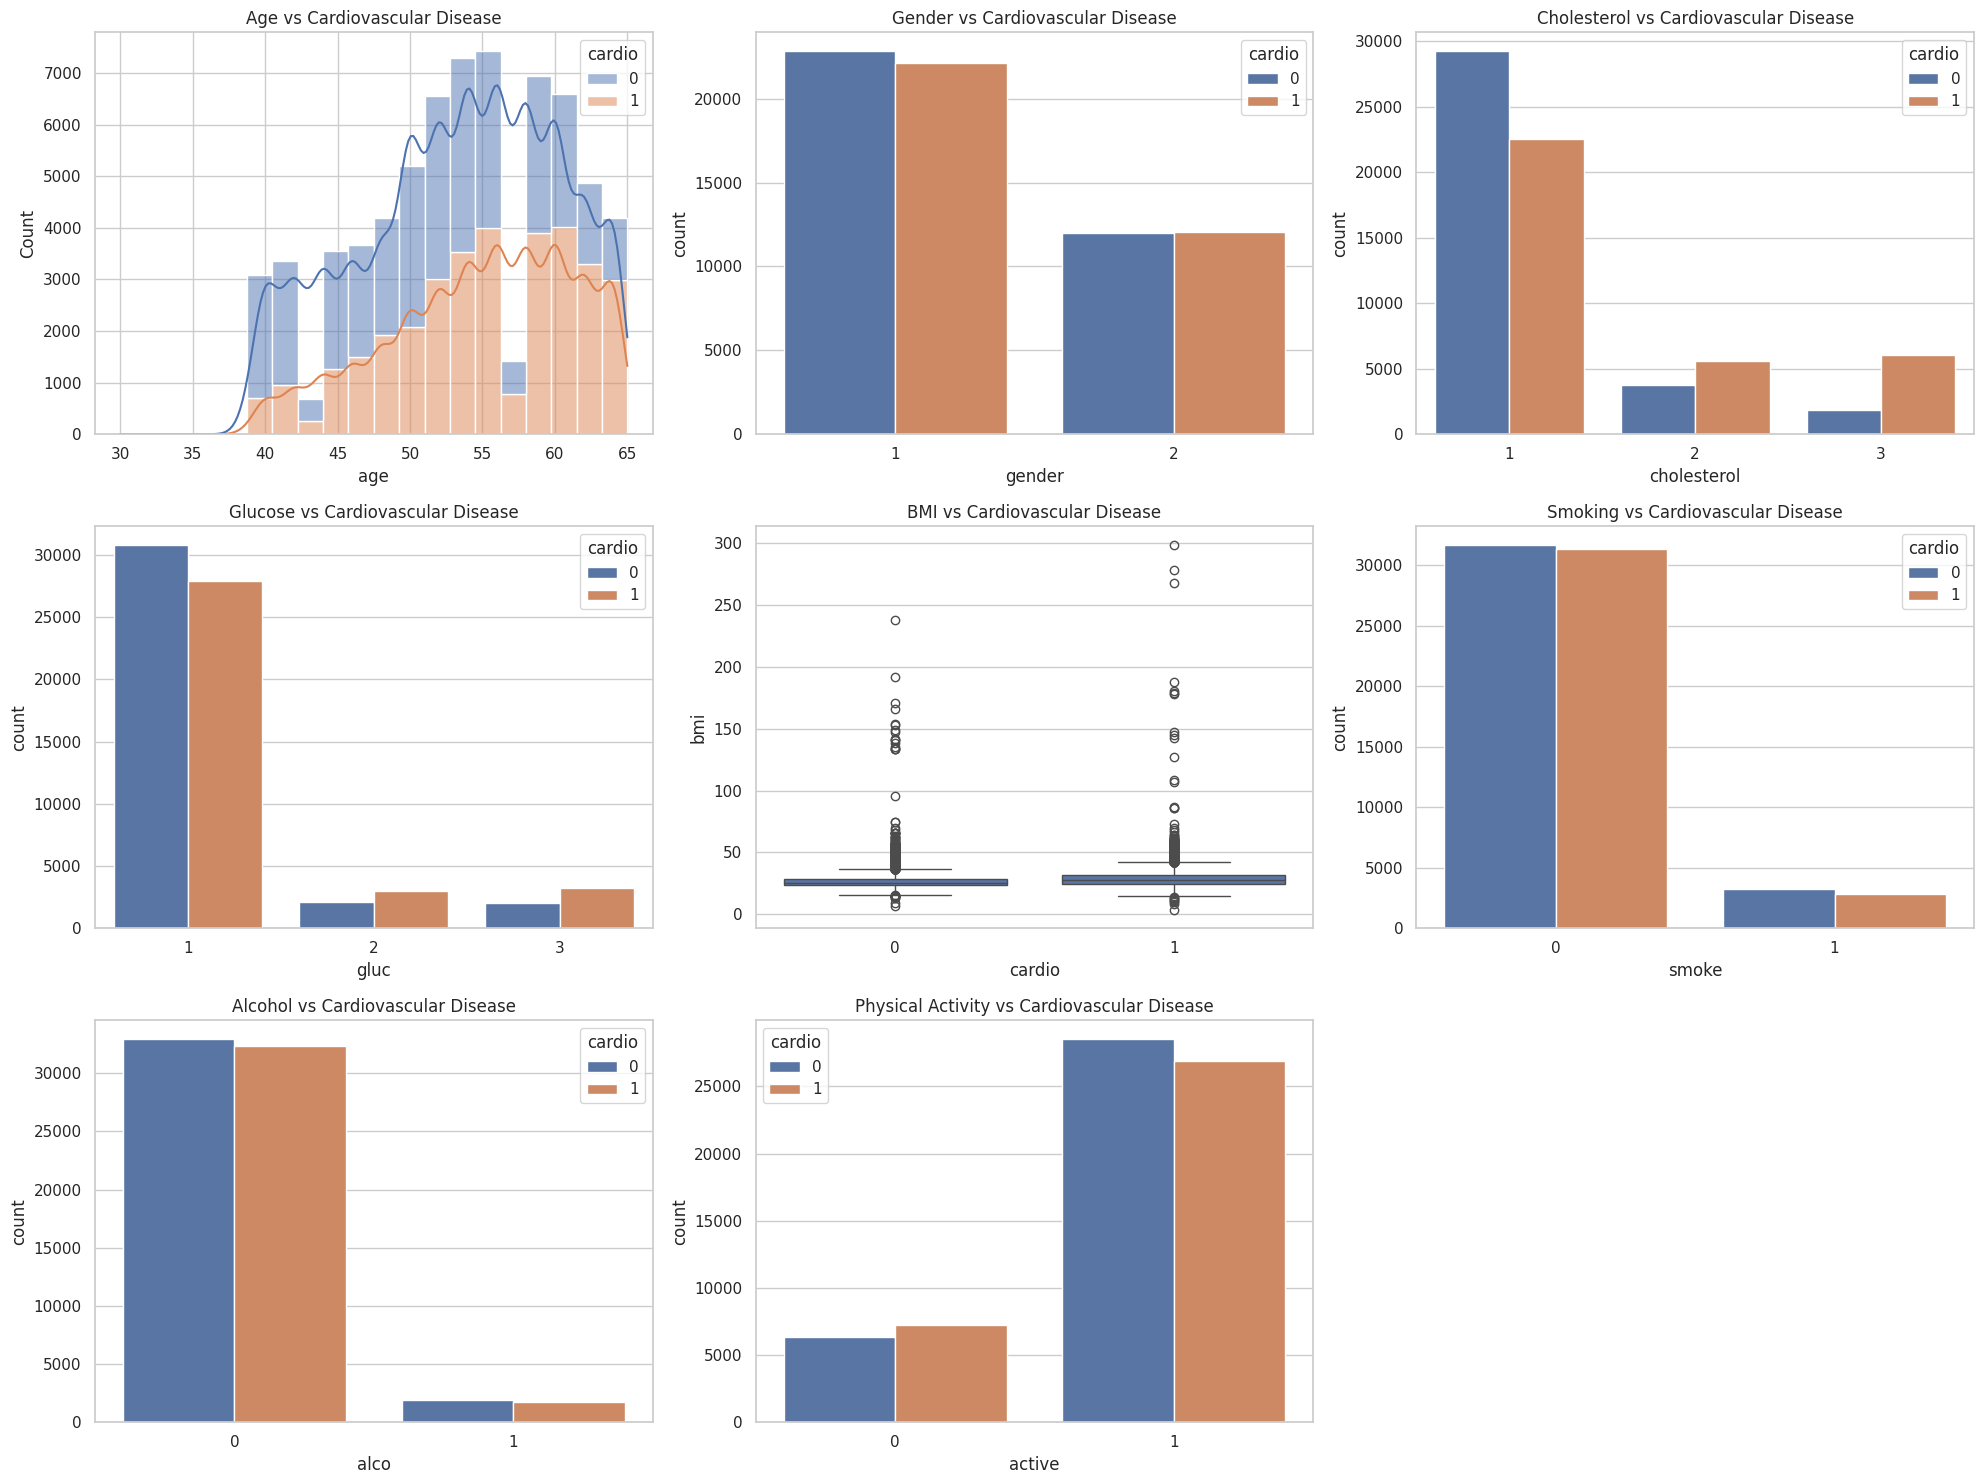

In [4]:
plt.figure(figsize=(20, 15))

plt.subplot(3, 3, 1)
sns.histplot(data=df, x='age', hue='cardio', multiple="stack", kde=True, bins=20)
plt.title('Age vs Cardiovascular Disease')

plt.subplot(3, 3, 2)
sns.countplot(x='gender', hue='cardio', data=df)
plt.title('Gender vs Cardiovascular Disease')

plt.subplot(3, 3, 3)
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title('Cholesterol vs Cardiovascular Disease')

plt.subplot(3, 3, 4)
sns.countplot(x='gluc', hue='cardio', data=df)
plt.title('Glucose vs Cardiovascular Disease')

plt.subplot(3, 3, 5)
sns.boxplot(x='cardio', y='bmi', data=df)
plt.title('BMI vs Cardiovascular Disease')

plt.subplot(3, 3, 6)
sns.countplot(x='smoke', hue='cardio', data=df)
plt.title('Smoking vs Cardiovascular Disease')

plt.subplot(3, 3, 7)
sns.countplot(x='alco', hue='cardio', data=df)
plt.title('Alcohol vs Cardiovascular Disease')

plt.subplot(3, 3, 8)
sns.countplot(x='active', hue='cardio', data=df)
plt.title('Physical Activity vs Cardiovascular Disease')

plt.tight_layout()
plt.show()


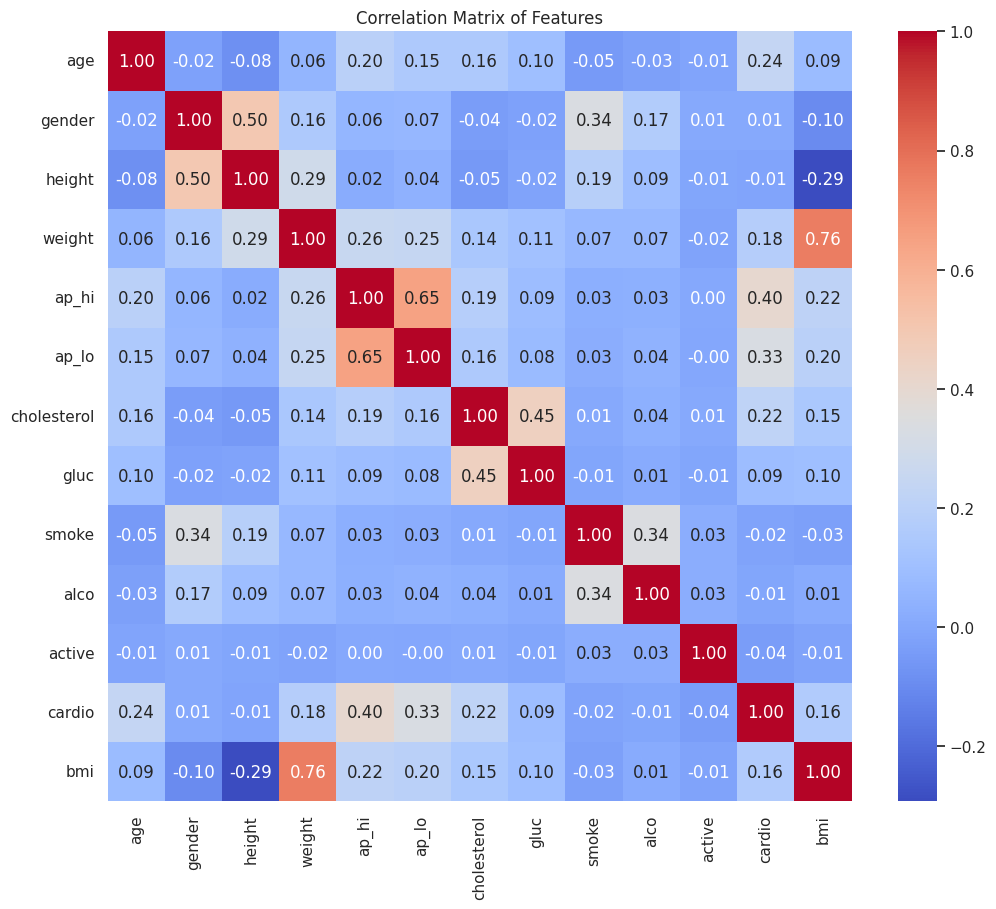

In [5]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()



Logistic Regression Accuracy: 0.7243
              precision    recall  f1-score   support

           0       0.70      0.78      0.74      6896
           1       0.75      0.67      0.71      6901

    accuracy                           0.72     13797
   macro avg       0.73      0.72      0.72     13797
weighted avg       0.73      0.72      0.72     13797



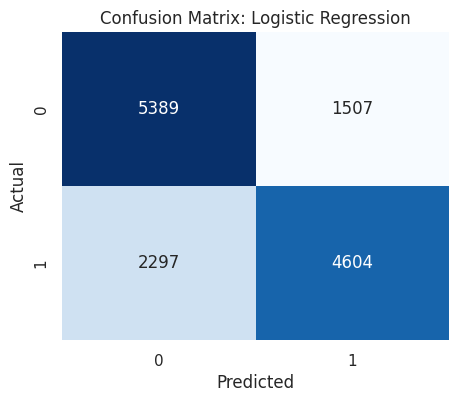


Decision Tree Accuracy: 0.6363
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      6896
           1       0.64      0.62      0.63      6901

    accuracy                           0.64     13797
   macro avg       0.64      0.64      0.64     13797
weighted avg       0.64      0.64      0.64     13797



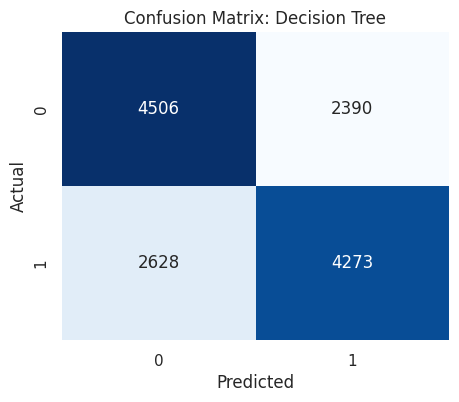


Random Forest Accuracy: 0.7091
              precision    recall  f1-score   support

           0       0.70      0.73      0.71      6896
           1       0.72      0.69      0.70      6901

    accuracy                           0.71     13797
   macro avg       0.71      0.71      0.71     13797
weighted avg       0.71      0.71      0.71     13797



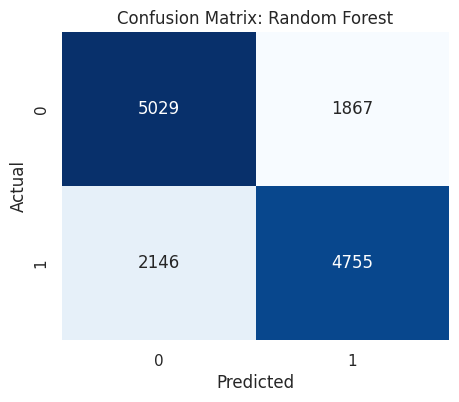


K-Nearest Neighbor Accuracy: 0.6923
              precision    recall  f1-score   support

           0       0.69      0.71      0.70      6896
           1       0.70      0.67      0.69      6901

    accuracy                           0.69     13797
   macro avg       0.69      0.69      0.69     13797
weighted avg       0.69      0.69      0.69     13797



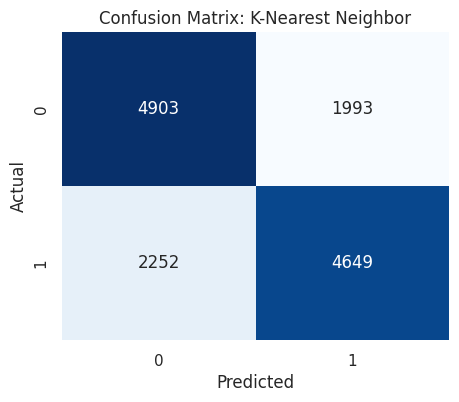


Support Vector Machine Accuracy: 0.7312
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6896
           1       0.76      0.67      0.71      6901

    accuracy                           0.73     13797
   macro avg       0.73      0.73      0.73     13797
weighted avg       0.73      0.73      0.73     13797



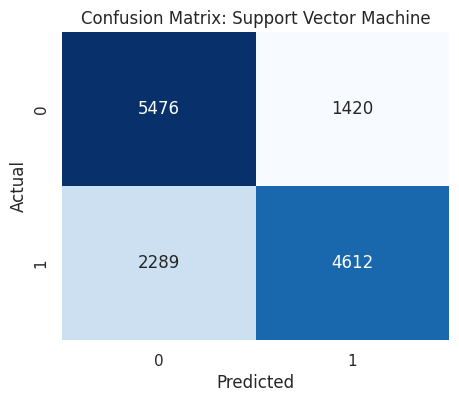

In [6]:
X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_accuracies = {}
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbor': KNeighborsClassifier(),
    'Support Vector Machine': SVC(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    model_accuracies[name] = acc

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


/tmp/ipython-input-1059912915.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="viridis")


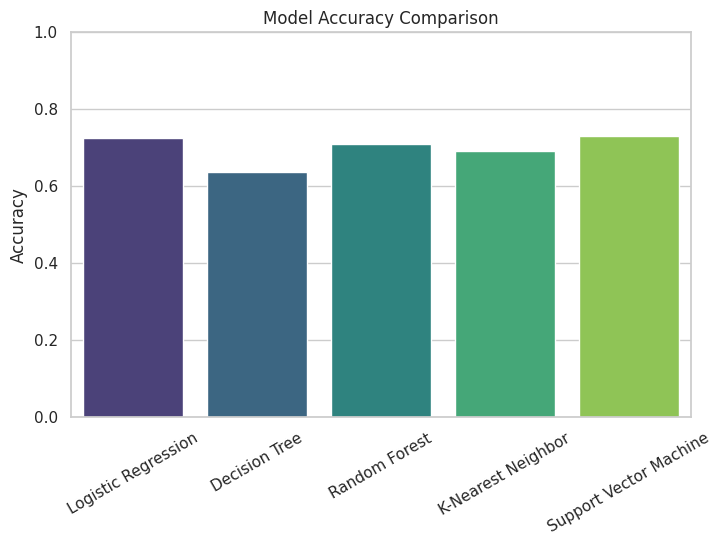

/tmp/ipython-input-1059912915.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="viridis")


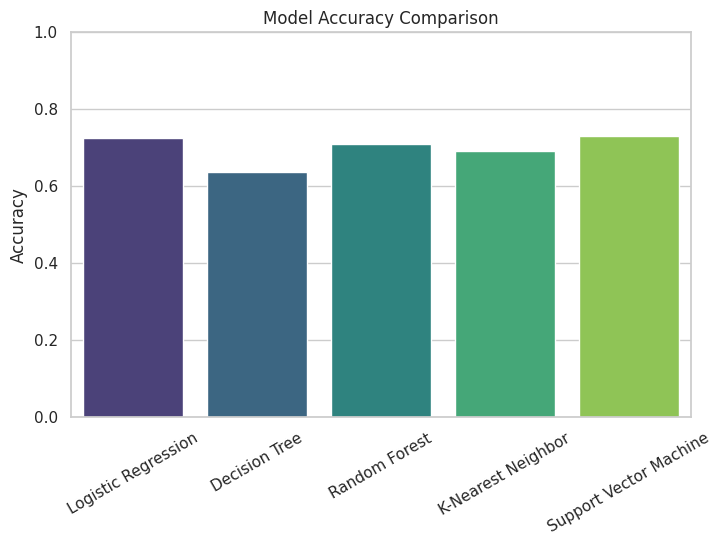

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="viridis")
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()


In [10]:
best_model_name = max(model_accuracies, key=model_accuracies.get)
print(f"Best Model: {best_model_name} with Accuracy: {model_accuracies[best_model_name]:.4f}")


Best Model: Support Vector Machine with Accuracy: 0.7312
Best Model: Support Vector Machine with Accuracy: 0.7312
